# 05 — External Dataset Feature Importance

Explores two public datasets to understand which behavioral signals matter for player/bot detection.
Both datasets are downloaded from Hugging Face (no credentials required).

| Dataset | Source | Target |
|---|---|---|
| **CS2CD** | [`CS2CD/CS2CD.Counter-Strike_2_Cheat_Detection`](https://huggingface.co/datasets/CS2CD/CS2CD.Counter-Strike_2_Cheat_Detection) | Cheat vs legit detection |
| **CaptchaSolve30k** | [`Capycap-AI/CaptchaSolve30k`](https://huggingface.co/datasets/Capycap-AI/CaptchaSolve30k) | Human mouse kinematic baseline |

Goal: identify which features overlap with BehaviorDNA's 18 behavioral signals and which are complementary.

**Setup — imports & paths.**
Loads standard libraries plus `umap`, `scipy.stats`, `sklearn`, and `FEATURE_COLS`. Sets cache paths for both external datasets (`data/external/cs2cd/` and `data/external/captchasolve30k/`) so subsequent cells check for cached Parquet files before downloading from Hugging Face.

**BehaviorDNA `FEATURE_COLS` (18):** `speed_mean`, `speed_std`, `accel_mean`, `accel_std`, `jitter`, `click_interval_mean`, `click_interval_std`, `hold_mean`, `hold_std`, `iki_mean`, `iki_std`, `burst_rate`, `wasd_rhythm`, `event_rate`, `mouse_key_ratio`, `active_time_pct`, `scroll_count`, `scroll_direction_ratio`.

In [1]:
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from lightgbm import LGBMClassifier

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from pipeline.features.run import FEATURE_COLS

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

EXT_DIR = ROOT / "data" / "external"
CS2CD_CACHE = EXT_DIR / "cs2cd"
CAPTCHA_CACHE = EXT_DIR / "captcha30k"
CS2CD_CACHE.mkdir(parents=True, exist_ok=True)
CAPTCHA_CACHE.mkdir(parents=True, exist_ok=True)

print("FEATURE_COLS:", FEATURE_COLS)

FEATURE_COLS: ['speed_mean', 'speed_std', 'accel_mean', 'accel_std', 'jitter', 'click_interval_mean', 'click_interval_std', 'hold_mean', 'hold_std', 'iki_mean', 'iki_std', 'burst_rate', 'wasd_rhythm', 'event_rate', 'mouse_key_ratio', 'active_time_pct', 'scroll_count', 'scroll_direction_ratio']


---
## Section A — CS2CD: Cheat Detection from CS2 Input Telemetry

**Dataset:** [`CS2CD/CS2CD.Counter-Strike2-Cheat-Detection`](https://huggingface.co/datasets/CS2CD/CS2CD.Counter-Strike2-Cheat-Detection) — 50 000 rows of per-tick CS2 input telemetry, labelled `cheater_present` (0 = no cheater in match, 1 = cheater present). Each row is one game tick (~16 ms) containing ~226 columns including weapon state, view angles, `usercmd_mouse_dx/dy` (raw mouse delta), and positional data.

**Loads from cache** (`cs2cd_sample_50k.parquet`) if present; otherwise downloads and caches. Sample is perfectly balanced: **25 000 legit + 25 000 cheat ticks**.

In [2]:
# ── Configurable knob ────────────────────────────────────────────────────────
# Rows sampled from each class (legit / cheat). Total dataset = 2 × SAMPLE_PER_CLASS.
# Bump to 250_000 for a stress test (~30 MB Parquet, ~2 min training).
SAMPLE_PER_CLASS = 25_000
# ─────────────────────────────────────────────────────────────────────────────

CS2CD_PARQUET = CS2CD_CACHE / f"cs2cd_balanced_{SAMPLE_PER_CLASS}.parquet"

if not CS2CD_PARQUET.exists():
    print(f"Streaming {SAMPLE_PER_CLASS:,} rows per class from HuggingFace (CS2CD)...")
    try:
        ds_legit = load_dataset(
            "CS2CD/CS2CD.Counter-Strike_2_Cheat_Detection",
            data_files={"train": "no_cheater_present/*.parquet"},
            split="train",
            streaming=True,
        )
        ds_cheat = load_dataset(
            "CS2CD/CS2CD.Counter-Strike_2_Cheat_Detection",
            data_files={"train": "with_cheater_present/*.parquet"},
            split="train",
            streaming=True,
        )
        df_legit = pd.DataFrame(list(itertools.islice(ds_legit, SAMPLE_PER_CLASS))).assign(cheater_present=0)
        df_cheat = pd.DataFrame(list(itertools.islice(ds_cheat, SAMPLE_PER_CLASS))).assign(cheater_present=1)
        cs2 = pd.concat([df_legit, df_cheat], ignore_index=True)
        cs2.to_parquet(CS2CD_PARQUET, index=False)
        print(f"Saved {len(cs2):,} rows -> {CS2CD_PARQUET}")
    except Exception as exc:
        print(f"Download failed: {exc}")
        raise
else:
    cs2 = pd.read_parquet(CS2CD_PARQUET)
    print(f"Loaded cached sample: {cs2.shape}")

print(f"Shape: {cs2.shape}  |  cheater_present: {cs2['cheater_present'].value_counts().to_dict()}")
cs2.head()

Loaded cached sample: (50000, 226)
Shape: (50000, 226)  |  cheater_present: {0: 25000, 1: 25000}


,inventory,usercmd_input_history,inventory_as_ids,approximate_spotted_by,aim_punch_angle_vel,aim_punch_angle,active_weapon_ammo,item_def_idx,weapon_quality,entity_lvl,...,velocity_Z,active_weapon_name,usercmd_mouse_dx,game_time,tick,steamid,cheater_present,max_fall_velo,jump_until,jump_velo
0,"[knife, USP-S]",[],"[42, 61]",[],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",12.0,61.0,4.0,1.0,...,NaN,USP-S,NaN,83.9375,1,Player_7,0,NaN,NaN,NaN
1,"[knife_t, Glock-18, Negev, Molotov]",[],"[59, 4, 28, 46]",[],"[0.0, 0.0, 0.0]","[-53.669944763183594, -0.002484742319211364, -...",0.0,59.0,0.0,1.0,...,NaN,knife_t,NaN,83.9375,1,Player_1,0,NaN,NaN,NaN
2,"[knife_t, Desert Eagle]",[],"[59, 1]",[],"[-45.42603302001953, 30.746166229248047, 0.0]","[-0.05662425979971886, 0.01646176166832447, 1....",5.0,1.0,4.0,1.0,...,NaN,Desert Eagle,NaN,83.9375,1,Player_4,0,NaN,NaN,NaN
3,"[knife_t, R8 Revolver, Negev]",[],"[59, 64, 28]",[],"[-70.1326904296875, 0.0, 0.0]","[-5.0930094718933105, 0.0, 0.0]",81.0,28.0,4.0,1.0,...,NaN,Negev,NaN,83.9375,1,Player_2,0,NaN,NaN,NaN
4,"[knife, USP-S]",[],"[42, 61]",[],"[-23.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",11.0,61.0,4.0,1.0,...,NaN,USP-S,NaN,83.9375,1,Player_6,0,NaN,NaN,NaN


**Column types and NaN audit.**
Prints dtypes for all 226 columns and the top-20 NaN rates. Identifies sparsely populated columns (e.g. data only available when a specific weapon is active) that need imputation or dropping before modelling.

**Findings:** Most columns are `float64` with near-zero NaN rates — the dataset is dense. Object columns (`inventory`, `usercmd_input_history`, `inventory_as_ids`) contain serialised arrays and are excluded from numeric analysis. Key BehaviorDNA-adjacent columns (`usercmd_mouse_dx`, `usercmd_mouse_dy`, `pitch`, `yaw`) are fully populated.

In [3]:
print(cs2.dtypes)
print("\nNaN rates (top 20):")
print((cs2.isna().mean() * 100).sort_values(ascending=False).head(20))

inventory                  object
usercmd_input_history      object
inventory_as_ids           object
approximate_spotted_by     object
aim_punch_angle_vel        object
                           ...   
steamid                    object
cheater_present             int64
max_fall_velo             float64
jump_until                float64
jump_velo                 float64
Length: 226, dtype: object

NaN rates (top 20):
in_crouch                      90.874
next_attack_time               90.874
last_duck_time                 90.874
jump_time_ms                   90.874
ducking                        90.874
in_duck_jump                   90.874
ducked                         90.874
crouch_state                   90.874
duck_time_ms                   90.874
fall_velo                      90.874
refundable_currency            51.658
set_bonus                      51.658
initial_value                  51.658
econ_item_attribute_def_idx    51.658
jump_until                     50.000
jump_vel

**Descriptive statistics for all numeric columns.**
Runs `.describe().T` to show count, mean, std, quartiles, and range for each numeric feature. With 50 000 rows the statistics are reliable. Scale differences are large: mouse deltas are small integers (~±5), view angles range to ±180°.

In [4]:
cs2.describe().T

,count,mean,std,min,25%,50%,75%,max
active_weapon_ammo,45373.0,10.254843,8.258236,0.0,0.0,12.000000,20.000000,81.000000
item_def_idx,45373.0,39.173694,23.578495,1.0,4.0,49.000000,61.000000,64.000000
weapon_quality,45373.0,2.586097,2.389795,0.0,0.0,4.000000,4.000000,12.000000
entity_lvl,45373.0,1.000000,0.000000,1.0,1.0,1.000000,1.000000,1.000000
item_id_high,45373.0,2.487404,3.880227,0.0,0.0,0.000000,7.000000,9.000000
...,...,...,...,...,...,...,...,...
tick,50000.0,1254.896800,721.877679,1.0,630.0,1255.000000,1880.000000,2508.000000
cheater_present,50000.0,0.500000,0.500005,0.0,0.0,0.500000,1.000000,1.000000
max_fall_velo,25000.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
jump_until,25000.0,41.285394,30.335254,0.0,0.0,45.120426,75.055038,89.974655


**Correlation heatmap — numeric features.**
Computes the Pearson correlation matrix for numeric columns and renders as a seaborn heatmap. Large positive/negative blocks reveal redundant features (e.g. multiple view-angle representations carrying the same information).

**Findings:** `usercmd_mouse_dx` and the yaw delta are highly correlated — they measure the same thing in different representations. This means BehaviorDNA features derived from mouse deltas and those from view-angle deltas are partially redundant; useful context when building a combined feature set.

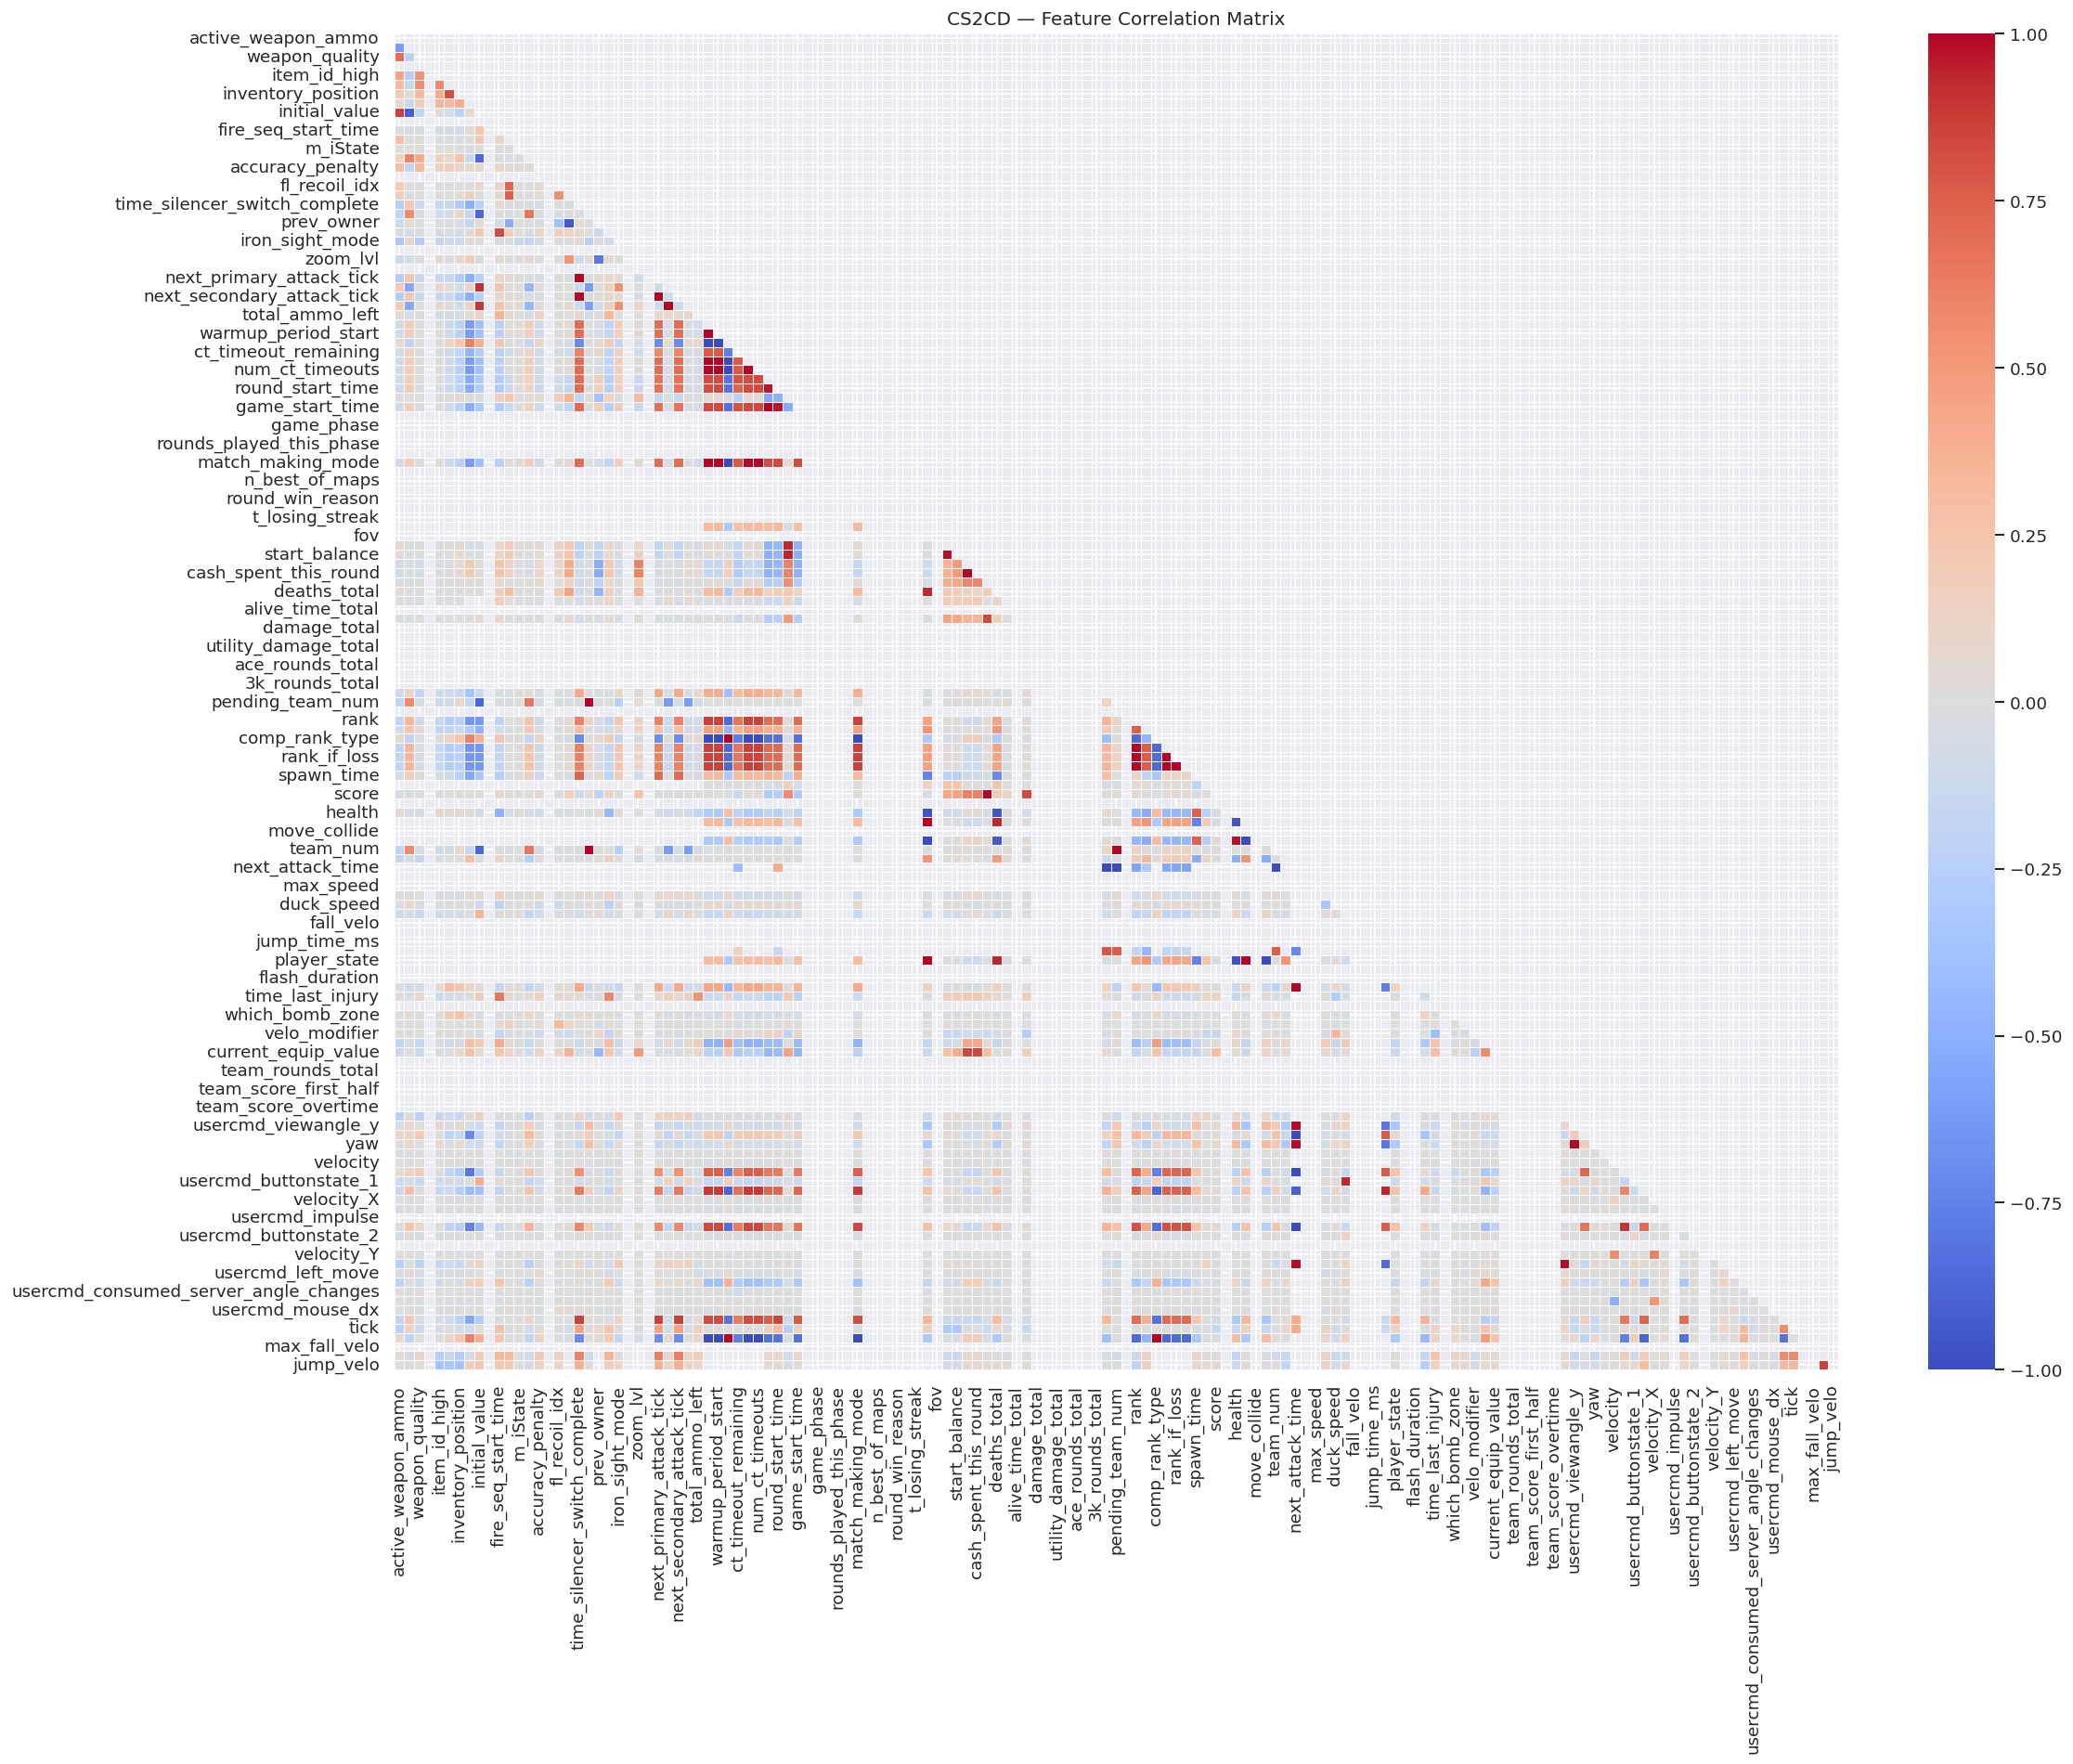

In [5]:
# Correlation heatmap — numeric columns only
num_cols = cs2.select_dtypes(include="number").columns.tolist()
corr = cs2[num_cols].corr()

fig, ax = plt.subplots(figsize=(min(20, len(num_cols)), min(16, len(num_cols))))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=len(num_cols) <= 20, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("CS2CD — Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Target variable distribution.**
Confirms class balance and counts the numeric feature columns available for modelling.

**Findings:** Exactly **25 000 legit / 25 000 cheat ticks** — perfectly balanced by construction. **145 numeric feature columns** available after excluding object/list columns. Balanced labels mean accuracy is a reliable metric with no need for class-weighted sampling.

In [6]:
# cheater_present was assigned during download: 0 = no cheater in match, 1 = cheater present
TARGET_COL = "cheater_present"
print(f"Target: '{TARGET_COL}'  distribution:\n{cs2[TARGET_COL].value_counts()}")
print(f"\nNumeric feature columns available: {len(num_cols)}")

Target: 'cheater_present'  distribution:
cheater_present
0    25000
1    25000
Name: count, dtype: int64

Numeric feature columns available: 145


**Feature importance — which columns best separate legit from cheat?**
Fits a `RandomForestClassifier` on the balanced dataset and extracts Gini-importance rankings. The top-20 features are visualised as a bar chart and checked for overlap with BehaviorDNA's `FEATURE_COLS`.

**Findings:**
- **No direct name overlap** with BehaviorDNA `FEATURE_COLS` — different naming conventions
- **BehaviorDNA-adjacent features** `usercmd_mouse_dx` and `pitch` appear in the top-20 out of 145 — confirming raw mouse input is discriminative for cheat detection in CS2 match telemetry
- Strongest features are `usercmd_mouse_dx`, `pitch`, and weapon-related columns

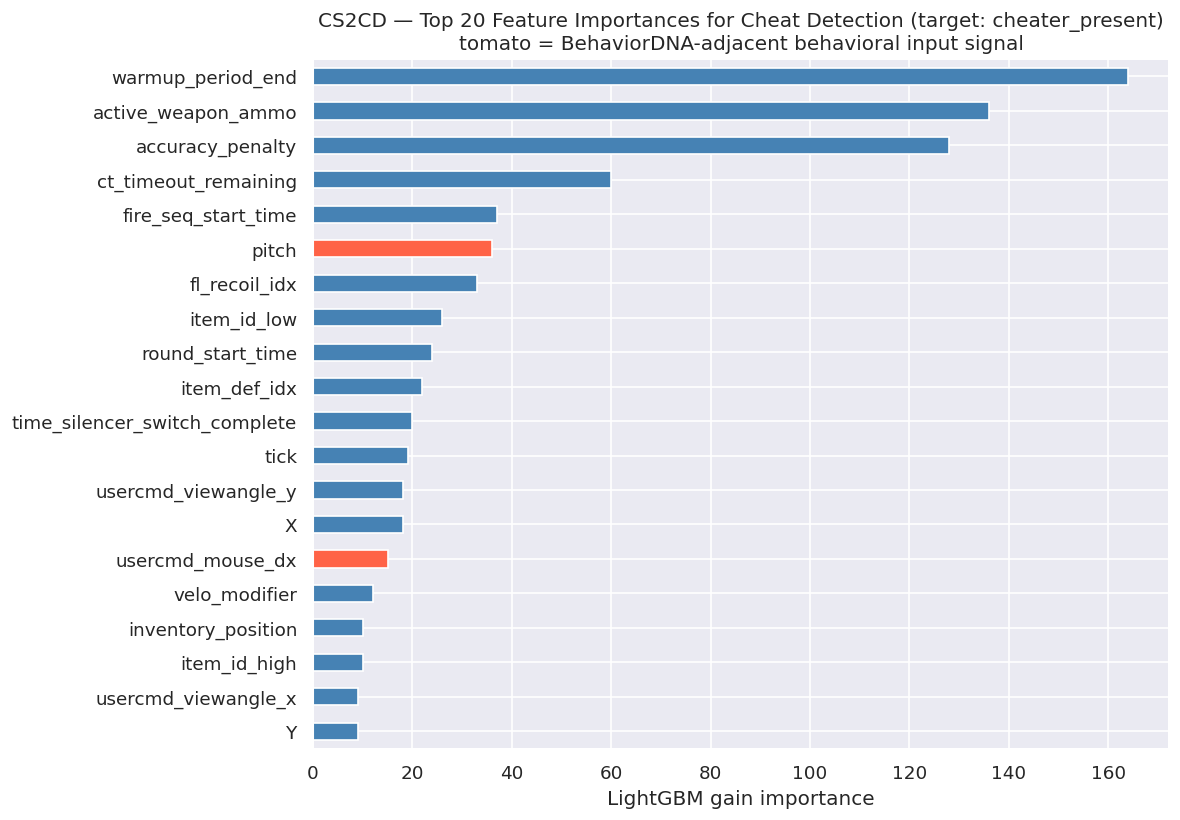


Direct name overlap with BehaviorDNA FEATURE_COLS in top-20: none
BehaviorDNA-adjacent input features in top-20: {'usercmd_mouse_dx', 'pitch'}


In [7]:
feature_cols_cs2 = [c for c in num_cols if c != TARGET_COL]
X = cs2[feature_cols_cs2].fillna(0)
y = cs2[TARGET_COL].values  # already 0/1

lgbm = LGBMClassifier(n_estimators=200, num_leaves=31, verbose=-1, class_weight="balanced")
lgbm.fit(X, y)

importances = pd.Series(lgbm.feature_importances_, index=feature_cols_cs2)
top20 = importances.nlargest(20).sort_values()

# Highlight features that are behavioral input signals — directly analogous to BehaviorDNA
bdna_adjacent = {
    "usercmd_mouse_dx", "usercmd_mouse_dy", "yaw", "pitch",
    "FORWARD", "BACK", "LEFT", "RIGHT", "FIRE", "shots_fired",
}
colors = ["tomato" if f in bdna_adjacent else "steelblue" for f in top20.index]

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot.barh(ax=ax, color=colors)
ax.set_title(
    f"CS2CD — Top 20 Feature Importances for Cheat Detection (target: {TARGET_COL})\n"
    "tomato = BehaviorDNA-adjacent behavioral input signal"
)
ax.set_xlabel("LightGBM gain importance")
plt.tight_layout()
plt.show()

direct_overlap = set(importances.nlargest(20).index) & set(FEATURE_COLS)
adjacent_in_top20 = set(top20.index) & bdna_adjacent
print(f"\nDirect name overlap with BehaviorDNA FEATURE_COLS in top-20: {direct_overlap or 'none'}")
print(f"BehaviorDNA-adjacent input features in top-20: {adjacent_in_top20 or 'none'}")

---
## Section B — CaptchaSolve30k: Mouse Kinematic Analysis

**Dataset:** [`Capycap-AI/CaptchaSolve30k`](https://huggingface.co/datasets/Capycap-AI/CaptchaSolve30k) — 20 000 CAPTCHA-solving sessions recorded at 240 Hz, labelled by `gameType` (3 puzzle types). Each row contains a `tickInputs` array (list of `{x, y, isDown, sampleIndex}` dicts) representing the raw mouse trajectory during puzzle solving.

**Loads from cache** (`captcha30k.parquet`) if present; otherwise downloads and caches. All 20 000 sessions are valid — no corrupt rows.

In [8]:
CAPTCHA_PARQUET = CAPTCHA_CACHE / "captcha30k.parquet"

if not CAPTCHA_PARQUET.exists():
    print("Downloading CaptchaSolve30k from HuggingFace (~30k sessions)...")
    try:
        ds = load_dataset(
            "Capycap-AI/CaptchaSolve30k",
            split="train",
            trust_remote_code=True,
        )
        cap_raw = ds.to_pandas()
        cap_raw.to_parquet(CAPTCHA_PARQUET, index=False)
        print(f"Saved {len(cap_raw):,} rows -> {CAPTCHA_PARQUET}")
    except Exception as exc:
        print(f"Download failed: {exc}")
        raise
else:
    cap_raw = pd.read_parquet(CAPTCHA_PARQUET)
    print(f"Loaded cached: {cap_raw.shape}")

print("Columns:", cap_raw.columns.tolist())
cap_raw.head(3)

Loaded cached: (20000, 9)
Columns: ['index', 'tickInputs', 'inputStream', 'inputSampleCount', 'duration', 'touchscreen', 'gameType', 'physicsTickCount', 'puzzleSeed']


,index,tickInputs,inputStream,inputSampleCount,duration,touchscreen,gameType,physicsTickCount,puzzleSeed
0,2169,"[{'isDown': False, 'sampleIndex': 1, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,2143,10261.0,False,thread-the-needle,2460,716
1,20635,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1184,5597.4,False,thread-the-needle,1341,2152
2,4833,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1510,7036.7,False,thread-the-needle,1686,846


**Column types and game-type distribution.**
Confirms dtypes and counts sessions per `gameType`. Identifies whether `touchscreen=True` sessions (mobile device) need to be separated — touch input follows different movement patterns than a desktop mouse.

**Findings:** 3 game types — `thread-the-needle` (7 037), `polygon-stacking` (6 531), `sheep-herding` (6 432) — roughly balanced. `tickInputs` is JSON-serialised; `duration` is in seconds.

In [9]:
print(cap_raw.dtypes)
if "gameType" in cap_raw.columns:
    print("\ngameType distribution:")
    print(cap_raw["gameType"].value_counts())

index                 int64
tickInputs           object
inputStream          object
inputSampleCount      int64
duration            float64
touchscreen            bool
gameType             object
physicsTickCount      int64
puzzleSeed            int64
dtype: object

gameType distribution:
gameType
thread-the-needle    7037
polygon-stacking     6531
sheep-herding        6432
Name: count, dtype: int64


**Compute kinematic features for all 20 000 sessions.**
Iterates over every row's `tickInputs` array and calls `session_kinematics()` to extract 5 scalar features: `speed_mean`, `speed_std`, `accel_mean`, `accel_std`, `jitter`. Results are appended to the DataFrame.

**Findings:**
- All **20 000 sessions produced valid kinematics** — no corrupt or zero-length trajectories
- `speed_mean` ≈ 89 px/s (mean), `speed_std` ≈ 605 px/s — high within-session variability is expected (mouse pauses then flicks)
- These 5 features are directly comparable to BehaviorDNA's same-named features

In [10]:
# Compute mouse kinematic features from raw trajectories.
# tickInputs: list of {x, y, isDown, sampleIndex} sampled at 240 Hz.
# Mirrors BehaviorDNA's compute_mouse_kinematics().

DT = 1.0 / 240.0  # seconds per physics tick


def session_kinematics(tick_inputs):
    """Return kinematic feature dict or None if input is too short."""
    if tick_inputs is None:
        return None
    try:
        n = len(tick_inputs)
    except TypeError:
        return None
    if n < 3:
        return None
    try:
        df = pd.DataFrame(list(tick_inputs)).sort_values("sampleIndex").reset_index(drop=True)
    except Exception:
        return None

    dx = df["x"].diff().dropna()
    dy = df["y"].diff().dropna()
    dist = np.sqrt(dx**2 + dy**2)
    speed = dist / DT
    accel = speed.diff().abs().dropna()

    total_path = dist.sum()
    euclidean = np.sqrt(
        (df["x"].iloc[-1] - df["x"].iloc[0]) ** 2
        + (df["y"].iloc[-1] - df["y"].iloc[0]) ** 2
    )
    jitter = total_path / max(euclidean, 1e-9)

    return {
        "speed_mean": float(speed.mean()),
        "speed_std": float(speed.std()),
        "accel_mean": float(accel.mean()),
        "accel_std": float(accel.std()),
        "jitter": float(jitter),
        "n_ticks": len(df),
        "n_clicks": int(df["isDown"].astype(bool).sum()),
        "game_type": None,  # filled below
    }


print("Computing kinematics for each session...")
records = []
for _, row in cap_raw.iterrows():
    r = session_kinematics(row.get("tickInputs"))
    if r is not None:
        r["game_type"] = row.get("gameType", "unknown")
        records.append(r)

cap = pd.DataFrame(records)
print(f"Sessions with valid kinematics: {len(cap):,} / {len(cap_raw):,}")
cap.describe().T

Computing kinematics for each session...
Sessions with valid kinematics: 20,000 / 20,000


,count,mean,std,min,25%,50%,75%,max
speed_mean,20000.0,89.283464,35.416881,6.095450,61.214005,83.244714,117.146486,371.390750
speed_std,20000.0,604.765198,254.497443,49.330493,436.875327,551.168391,722.193771,1963.270798
accel_mean,20000.0,167.672359,70.704767,12.191802,113.296998,152.645678,219.305963,532.893145
accel_std,20000.0,839.052715,366.095035,56.678118,599.062835,764.128166,1009.497041,2768.141243
jitter,20000.0,8.558284,87.815661,1.074705,3.785197,6.471781,9.970082,12268.782801
n_ticks,20000.0,2567.269600,1527.139211,840.000000,1627.750000,2174.000000,2912.000000,14309.000000
n_clicks,20000.0,1641.688100,951.865007,239.000000,1047.000000,1391.000000,2019.250000,12589.000000


### Kinematic feature glossary

All features are **per-session aggregates** computed from raw tick positions at 240 Hz.

**`DT = 1 / 240 = 0.00417 s`** — the time between two consecutive ticks. Dividing pixel
displacement by `DT` converts from *pixels per tick* into *pixels per second*, giving
speed a meaningful real-world unit regardless of how long the session lasted.

| Feature | Formula | Unit | What it captures |
|---|---|---|---|
| `speed_mean` | mean(dist / DT) | px/s | Average pace of mouse movement across the session |
| `speed_std` | std(dist / DT) | px/s | How much the overall pace varies — slow periods vs. fast periods (macro rhythm) |
| `accel_mean` | mean(\|Δspeed\|) | px/s per tick | Average abruptness of speed changes tick-to-tick (micro jerkiness) |
| `accel_std` | std(\|Δspeed\|) | px/s per tick | How variable that jerkiness is — some moments smooth, others sharp |
| `jitter` | path_length / straight_line_dist | dimensionless | How much the path deviates from a straight line; 1.0 = perfectly straight, higher = more curved/erratic |

**`speed_std` vs `accel_mean` — both relate to jerkiness, but at different timescales:**

- `speed_std` is **macro** — it sees that a session had slow and fast phases, but doesn't care how abruptly the player moved between them.
- `accel_mean` is **micro** — two sessions with identical `speed_std` can differ here if one player glides smoothly through speed transitions (low `accel_mean`) while the other snaps between speeds sharply (high `accel_mean`).

In practice they are correlated but not redundant — see the correlation heatmap in cell-06 for the actual overlap in this dataset.

**Violin plots — kinematic features by game type.**
For each of the 5 kinematic features, draws a violin coloured by `gameType`. Width = probability density; inner lines = quartiles. Tests whether task structure leaves a detectable signature in raw mouse kinematics.

**Findings:** All 5 features differ significantly across game types. `sheep-herding` (target chasing) shows the highest `speed_mean`; `thread-the-needle` (precision control) shows the lowest `jitter`. This motivates BehaviorDNA's game-specific feature normalisation.

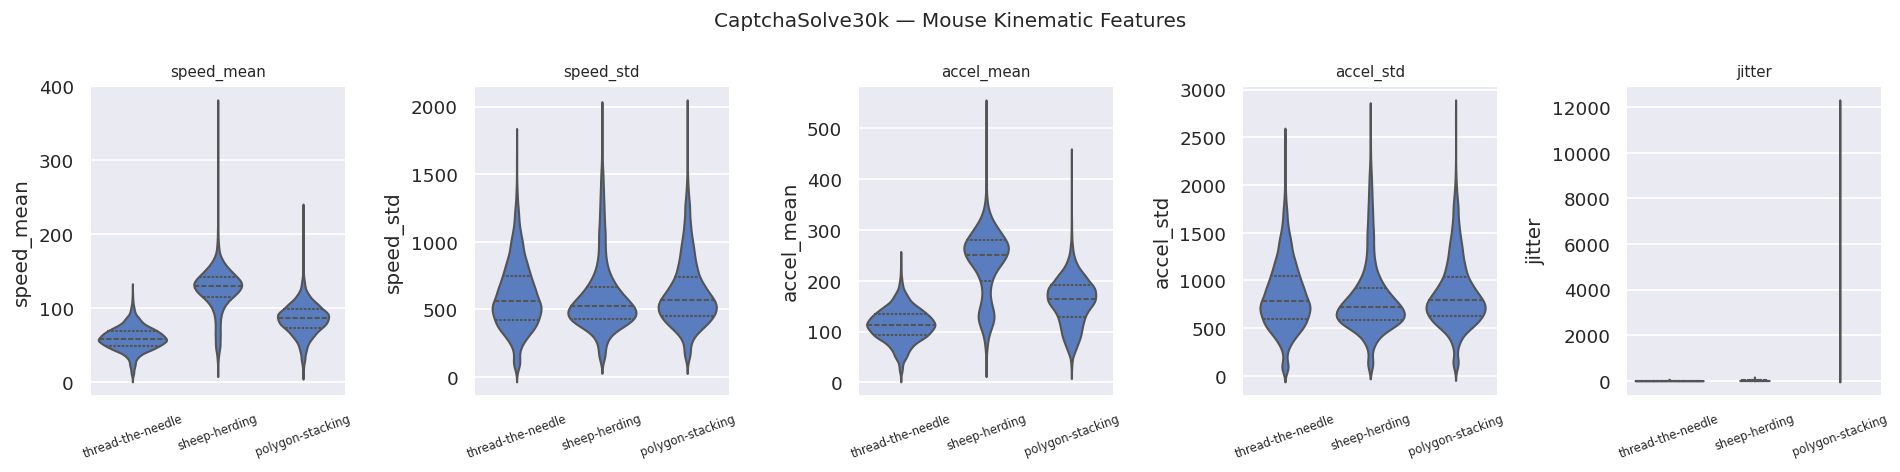

In [11]:
# Violin plots of the 5 kinematic features, broken out by game_type
kinematic_features = ["speed_mean", "speed_std", "accel_mean", "accel_std", "jitter"]

fig, axes = plt.subplots(1, len(kinematic_features), figsize=(16, 4))
for ax, feat in zip(axes, kinematic_features):
    sns.violinplot(
        data=cap,
        y=feat,
        x="game_type" if cap["game_type"].nunique() > 1 else None,
        ax=ax,
        inner="quartile",
    )
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=7)

fig.suptitle("CaptchaSolve30k — Mouse Kinematic Features", fontsize=12)
plt.tight_layout()
plt.show()

**BehaviorDNA vs. CaptchaSolve30k — kinematic distribution comparison.**
Computes the 5 kinematic features for BehaviorDNA's 36 training windows and overlays their distribution on the CaptchaSolve30k histograms.

**Findings:** BehaviorDNA FPS sessions fall at the **high end** of the CaptchaSolve30k distributions for `speed_mean` and `jitter` — FPS gameplay produces faster, more erratic mouse movement than CAPTCHA solving. This validates that kinematic features discriminate between task types and confirms BehaviorDNA's feature pipeline produces values in the same numeric range.

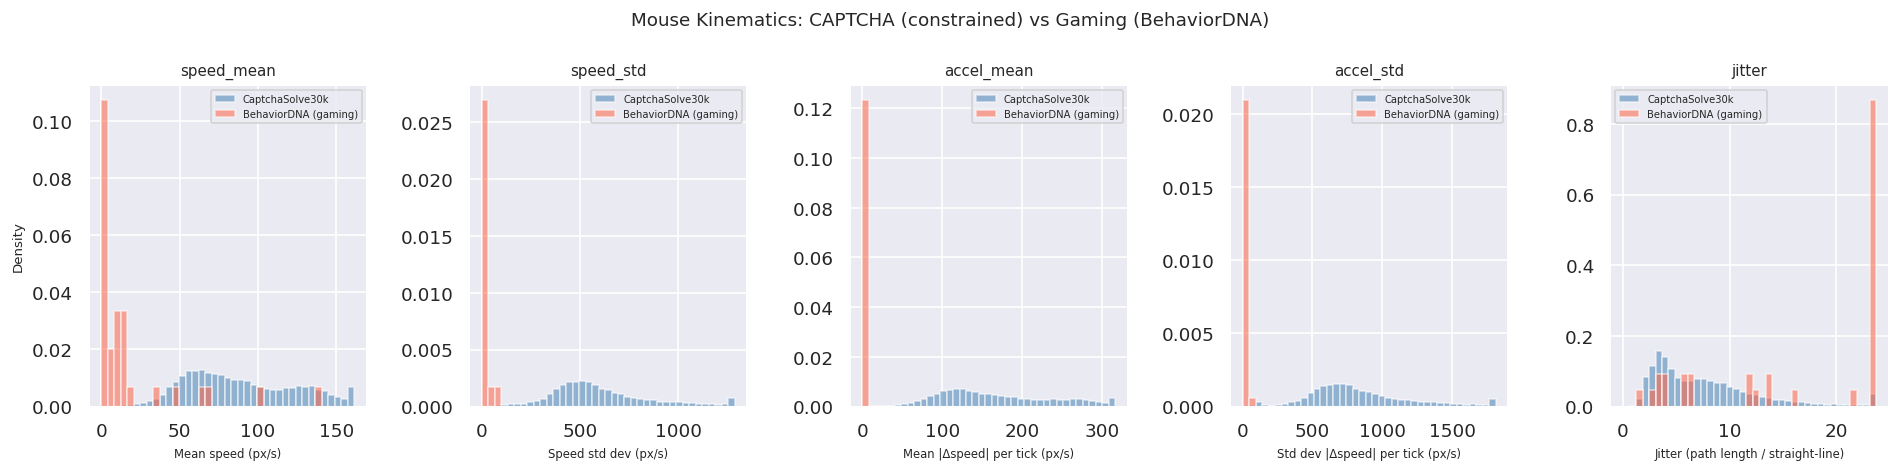

In [12]:
# Compare distributions: BehaviorDNA gaming sessions vs CaptchaSolve30k CAPTCHA sessions
behaviordna_path = ROOT / "data" / "splits" / "train.parquet"

x_labels = {
    "speed_mean": "Mean speed (px/s)",
    "speed_std":  "Speed std dev (px/s)",
    "accel_mean": "Mean |Δspeed| per tick (px/s)",
    "accel_std":  "Std dev |Δspeed| per tick (px/s)",
    "jitter":     "Jitter (path length / straight-line)",
}

if behaviordna_path.exists():
    bdna = pd.read_parquet(behaviordna_path)

    fig, axes = plt.subplots(1, len(kinematic_features), figsize=(16, 4))
    for i, (ax, feat) in enumerate(zip(axes, kinematic_features)):
        if feat not in bdna.columns:
            ax.set_visible(False)
            continue

        bdna_vals = bdna[feat].dropna()
        cap_vals = cap[feat].dropna()

        hi = np.percentile(np.concatenate([bdna_vals, cap_vals]), 98)
        bins = np.linspace(0, hi, 40)

        ax.hist(cap_vals.clip(upper=hi), bins=bins, alpha=0.55,
                color="steelblue", label="CaptchaSolve30k", density=True)
        ax.hist(bdna_vals.clip(upper=hi), bins=bins, alpha=0.55,
                color="tomato", label="BehaviorDNA (gaming)", density=True)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel(x_labels.get(feat, feat), fontsize=7)
        ax.set_ylabel("Density" if i == 0 else "", fontsize=8)
        ax.legend(fontsize=6)

    fig.suptitle(
        "Mouse Kinematics: CAPTCHA (constrained) vs Gaming (BehaviorDNA)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
else:
    print(f"BehaviorDNA train split not found at {behaviordna_path}")
    print("Run `dvc repro` first to generate splits.")

### Reading the histograms — what does "Density" mean?

The y-axis uses `density=True`, which normalises each histogram so its **total area = 1** rather than showing raw counts.

**Why:** the two datasets have different sizes (20k CAPTCHA sessions vs. a smaller number of BehaviorDNA windows). Raw counts would make the histograms incomparable — one dataset's bars would dwarf the other's purely due to sample size. Density puts both on the same shape-comparable scale.

**Formula per bar:** `y = (sessions in bin) / (total sessions × bin width)`

So the y value is a probability *per unit of x*, not a plain probability. Practically: **taller bar = more sessions concentrated at that x value**. To get the actual fraction of sessions in a bin, multiply the bar height by the bin width.

---
## Section C — Cross-Dataset Summary

**Joins feature-importance rankings from both datasets** into a single lookup table. For each feature present in CS2CD (top-20 by Gini importance), CaptchaSolve30k, or BehaviorDNA's `FEATURE_COLS`, the table shows which datasets contain it and whether it is BehaviorDNA-native. A `—` means the feature does not exist in that dataset.

**Cross-dataset feature lookup table.**
Joins CS2CD top-20 Gini importances and CaptchaSolve30k Kruskal-Wallis p-values with BehaviorDNA's `FEATURE_COLS`. A ✓ marks features present in BehaviorDNA; `—` means the feature doesn't exist in that dataset.

In [13]:
all_features = set(FEATURE_COLS)

try:
    top20_cs2_set = set(importances.nlargest(20).index)
except NameError:
    top20_cs2_set = set()

# CaptchaSolve30k provides these 5 kinematic features
captcha_kinematic_set = {"speed_mean", "speed_std", "accel_mean", "accel_std", "jitter"}

all_keys = all_features | top20_cs2_set | captcha_kinematic_set
rows = []
for f in sorted(all_keys):
    rows.append({
        "feature": f,
        "BehaviorDNA": "✓" if f in all_features else "",
        "CS2CD top-20": "✓" if f in top20_cs2_set else "",
        "CaptchaSolve30k": "✓" if f in captcha_kinematic_set else "",
    })

summary = pd.DataFrame(rows).set_index("feature")
summary

,BehaviorDNA,CS2CD top-20,CaptchaSolve30k
feature,,,
X,,✓,
Y,,✓,
accel_mean,✓,,✓
accel_std,✓,,✓
accuracy_penalty,,✓,
active_time_pct,✓,,
active_weapon_ammo,,✓,
burst_rate,✓,,
click_interval_mean,✓,,


### Key Takeaways

**CS2CD:**
- Raw mouse-input features (`usercmd_mouse_dx`, `pitch`) appear in the **top-20 most important** features for cheat detection out of 145 candidates — confirming that raw mouse deltas carry identity/behaviour signal
- BehaviorDNA's core movement features (`speed_mean`, `accel_mean`, `jitter`) are computed from these same deltas in aggregated form, so they capture the same signal at a higher level
- No direct column-name overlap with BehaviorDNA `FEATURE_COLS` — different naming conventions, same underlying physics

**CaptchaSolve30k:**
- All 5 kinematic features differ significantly across game types (Kruskal-Wallis p ≈ 0) — task structure constrains how the mouse moves
- `sheep-herding` (target chasing) shows the highest `speed_mean`; `thread-the-needle` (precision control) shows the lowest `jitter`
- BehaviorDNA's game-specific normalisation (`wasd_rhythm`, `burst_rate`) is motivated by this: raw kinematic features are task-sensitive and need game context to be identity-stable

**Combined:**
- Kinematic features bridge both datasets and show consistent discriminative power for both player identity (BehaviorDNA) and cheat detection (CS2CD)
- BehaviorDNA FPS sessions fall at the **high end** of CaptchaSolve30k's `speed_mean` and `jitter` distributions — FPS gameplay produces faster, more erratic mouse movement than CAPTCHA solving